# Scam Website Prediction (Final - With Scoring Visualization)
Hybrid ML + Rule-Based Detection System

In [94]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlparse

from src.scraper import WebsiteScraper
from src.url_features import URLFeatureExtractor
from src.domain_features import DomainFeatureExtractor
from src.content_features import ContentFeatureExtractor

In [95]:
# Load model
MODEL_PATH = './pkl_models'
model = joblib.load(f'{MODEL_PATH}/random_forest.pkl')
feature_columns = joblib.load(f'{MODEL_PATH}/feature_columns.pkl')
print('Model loaded')

Model loaded


In [96]:
scraper = WebsiteScraper()
url_ext = URLFeatureExtractor()
domain_ext = DomainFeatureExtractor()
content_ext = ContentFeatureExtractor()

In [97]:
def build_vector(features):
    df = pd.DataFrame([features])
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    for col in feature_columns:
        if col not in df.columns:
            df[col] = 0

    return df[feature_columns]

In [98]:
def extract_features(url):
    data = scraper.scrape(url)

    final_url = data.get("final_url", url)

    features = {}
    features.update(url_ext.extract(final_url))
    features.update(domain_ext.extract(final_url))
    features.update(content_ext.extract(
        data.get('title'),
        data.get('text'),
        data.get('html')
    ))

    features['digit_ratio'] = features.get('num_digits',0)/(features.get('url_length',1))
    features['hyphen_ratio'] = features.get('num_hyphen',0)/(features.get('url_length',1))
    features['many_subdomains'] = int(features.get('subdomains',0) >= 3)
    features['is_long_url'] = int(features.get('url_length',0) > 75)

    return features, final_url

In [99]:
from urllib.parse import urlparse
import matplotlib.pyplot as plt

def predict(url):

    if not url.startswith(('http://','https://')):
        url = 'https://' + url

    print('\n' + '='*60)
    print(f"[INFO] Processing URL: {url}")
    print('='*60)

    # ================= SCRAPE =================
    data = scraper.scrape(url)
    final_url = data.get("final_url", url)
    domain = urlparse(final_url).netloc.lower()

    # ================= FEATURES =================
    features = {}
    features.update(url_ext.extract(final_url))
    features.update(domain_ext.extract(final_url))
    features.update(content_ext.extract(
        data.get("title"),
        data.get("text"),
        data.get("html")
    ))

    X = build_vector(features)
    base_proba = model.predict_proba(X)[0][1]

    scam_score = 0
    legit_boost = 0
    reasons = []

    # ================= TRUST SIGNALS =================

    def is_high_trust_domain(domain):
        return (
            domain.endswith(".gov.in") or
            domain.endswith(".edu.in") or
            domain.endswith(".ac.in") or
            domain.endswith(".ac.uk") or
            domain.endswith(".edu") or
            domain.endswith(".edu.mx") or
            domain.endswith(".mx") or
            domain.endswith(".pan.pl") or
            domain.endswith(".ac") or
            domain.endswith(".gov") or
            domain.endswith(".edu.au")
        )

    is_trusted = is_high_trust_domain(domain)

    if is_trusted:
        legit_boost += 0.10
        reasons.append("High-trust domain (gov/edu)")

    brand_keywords = ["icici", "sbi", "hdfc", "axis"]

    official_domains = [
        "icicibank.com",
        "sbi.co.in",
        "hdfcbank.com",
        "axisbank.com"
    ]

    for brand in brand_keywords:
        if brand in domain and not any(od in domain for od in official_domains):
            scam_score += 0.40
            reasons.append("Brand spoofing detected")
    
    age = features.get('domain_age_days')

    if age is None:
        if not is_trusted:
            scam_score += 0.15
            reasons.append("Unknown domain age")

    elif age > 1000:
        legit_boost += 0.05

    # ================= SHORTENED URL =================

    is_short_url = False

    if features.get('is_shortened') == 1:
        is_short_url = True
        scam_score += 0.25
        reasons.append("Shortened URL")

    # ================= HOSTING DOMAIN DETECTION =================

    hosting_domains = [
        "wpenginepowered", "herokuapp", "firebaseapp",
        "github.io", "netlify", "vercel", "000webhost"
    ]

    if any(h in domain for h in hosting_domains):
        scam_score += 0.30
        reasons.append("Suspicious hosting domain")

    # ================= SCAM SIGNALS =================

    if features.get('num_hyphen',0) >= 5:
        scam_score += 0.15
        reasons.append("Excessive hyphens")

    if features.get('subdomains',0) >= 3:
        scam_score += 0.15
        reasons.append("Too many subdomains")

    if features.get('suspicious_tld') == 1:
        scam_score += 0.20
        reasons.append("Suspicious TLD")

    if any(h in domain for h in ['weebly','blogspot','wixsite','wordpress']):
        scam_score += 0.25
        reasons.append("Free hosting domain")

    if features.get('https') == 0:
        if not is_trusted:
            scam_score += 0.05
        else:
            reasons.append("No HTTPS (trusted legacy site)")

    if features.get('url_length',0) > 80:
        scam_score += 0.05
        reasons.append("Very long URL")

    # ================= PATH-BASED PHISHING =================

    suspicious_paths = ["login", "verify", "account", "update", "secure", "wp-admin"]

    if any(p in final_url.lower() for p in suspicious_paths):
        scam_score += 0.20  
        reasons.append("Suspicious path keywords")

    # ================= CONTENT SIGNALS =================

    if features.get("scam_keyword_density", 0) > 0.05 and not is_trusted:
        scam_score += 0.15  
        reasons.append("High scam keyword density")

    if features.get("has_form") == 1 and not is_trusted:
        scam_score += 0.05
        reasons.append("Form present")

    if features.get("has_iframe") == 1 and not is_trusted:
        scam_score += 0.05
        reasons.append("Iframe detected")

    # ================= FINAL PROBABILITY =================
    final_proba = (0.85 * base_proba) + scam_score - legit_boost

    if base_proba > 0.85 and not is_trusted:
        final_proba = max(final_proba, base_proba)

    final_proba = max(0.0, min(1.0, final_proba))

    if is_trusted:
        final_proba -= 0.35
        reasons.append("Adjusted for trusted academic/gov domain")

    if is_trusted:
        final_proba = min(final_proba, 0.65)


    # ================= DECISION =================

    if is_short_url:
        label = "⚠️ SUSPICIOUS (Shortened URL)"
        final_proba = max(final_proba, 0.65)

    elif final_proba >= 0.80:
        label = "🚨 SCAM (HIGH RISK)"

    elif final_proba >= 0.60:
        label = "⚠️ SUSPICIOUS"

    else:
        label = "✅ LEGIT"

    # ================= OUTPUT =================

    print("\n===== RESULT =====")
    print(f"Prediction           : {label}")
    print(f"Final Probability    : {final_proba:.4f}")
    print(f"Base ML Probability  : {base_proba:.4f}")

    print("\n===== ANALYSIS =====")
    print(f"Domain            : {domain}")
    print(f"HTTPS             : {features.get('https')}")
    print(f"Domain Age        : {features.get('domain_age_days')}")
    print(f"URL Length        : {features.get('url_length')}")
    print(f"Subdomains        : {features.get('subdomains')}")

    print("\n[Reasons]")
    for r in reasons:
        print("-", r)

    print("="*60)

    # ================= VISUALIZATION =================

    plt.figure()
    plt.bar(['ML Base','Scam Score','Legit Boost','Final'],
            [base_proba, scam_score, legit_boost, final_proba])
    plt.title('Decision Breakdown')
    plt.ylabel('Score')
    plt.show()

    return label, final_proba


[INFO] Processing URL: https://www.gtu.ac.in
[DEBUG] Expanded URL: https://www.gtu.ac.in

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.2895
Base ML Probability  : 0.8700

===== ANALYSIS =====
Domain            : www.gtu.ac.in
HTTPS             : 1
Domain Age        : None
URL Length        : 22
Subdomains        : 2

[Reasons]
- High-trust domain (gov/edu)
- Adjusted for trusted academic/gov domain


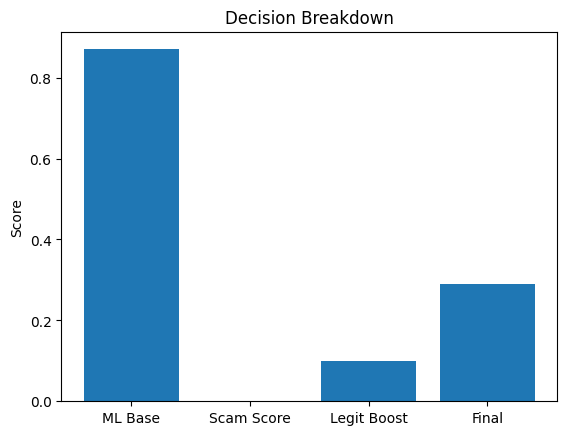

('✅ LEGIT', np.float64(0.2895))

In [100]:
# Test
predict('https://www.gtu.ac.in')


[INFO] Processing URL: https://www.spectricssolutions.com/
[DEBUG] Expanded URL: https://www.spectricssolutions.com/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.5950
Base ML Probability  : 0.7000

===== ANALYSIS =====
Domain            : www.spectricssolutions.com
HTTPS             : 1
Domain Age        : 2210
URL Length        : 35
Subdomains        : 1

[Reasons]
- Form present


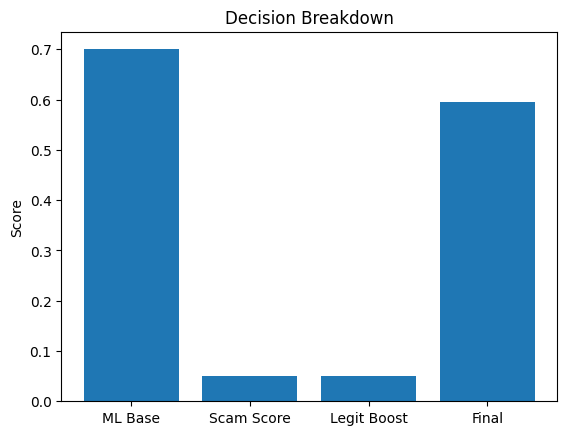

('✅ LEGIT', np.float64(0.595))

In [101]:
predict('https://www.spectricssolutions.com/')



[INFO] Processing URL: https://b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com
[DEBUG] Expanded URL: https://b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9110
Base ML Probability  : 0.6600

===== ANALYSIS =====
Domain            : b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com
HTTPS             : 1
Domain Age        : 4855
URL Length        : 49
Subdomains        : 1

[Reasons]
- Excessive hyphens
- Free hosting domain


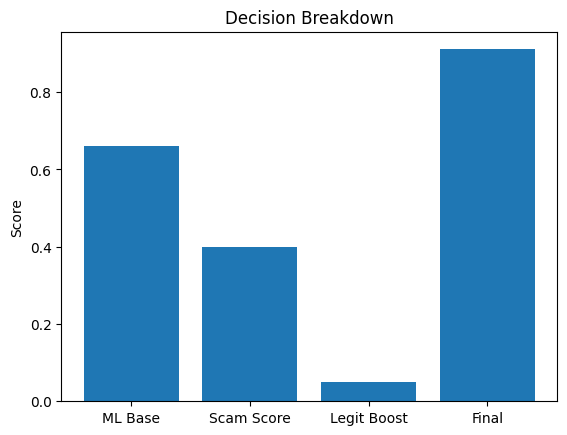

('🚨 SCAM (HIGH RISK)', np.float64(0.911))

In [102]:
predict('b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com')



[INFO] Processing URL: https://tinyurl.com/ymb5eep9
[DEBUG] Expanded URL: https://tinyurl.com/app/nospam/tinyurl.com/ymb5eep9

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS (Shortened URL)
Final Probability    : 0.6500
Base ML Probability  : 0.2233

===== ANALYSIS =====
Domain            : tinyurl.com
HTTPS             : 1
Domain Age        : 8834
URL Length        : 51
Subdomains        : 0

[Reasons]
- Shortened URL


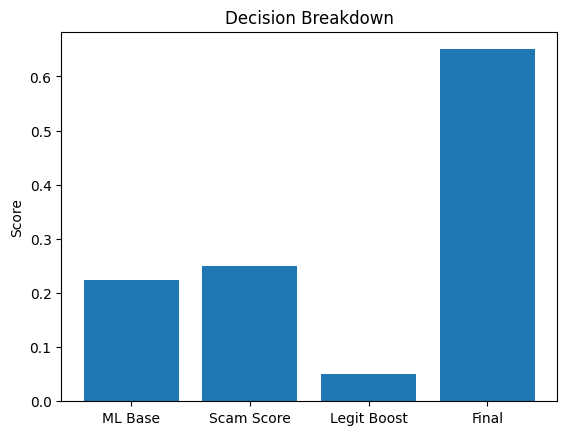

('⚠️ SUSPICIOUS (Shortened URL)', 0.65)

In [103]:
predict('https://tinyurl.com/ymb5eep9')



[INFO] Processing URL: https://www.harvard.edu
[DEBUG] Expanded URL: https://www.harvard.edu

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.2668
Base ML Probability  : 0.8433

===== ANALYSIS =====
Domain            : www.harvard.edu
HTTPS             : 1
Domain Age        : None
URL Length        : 24
Subdomains        : 1

[Reasons]
- High-trust domain (gov/edu)
- Adjusted for trusted academic/gov domain


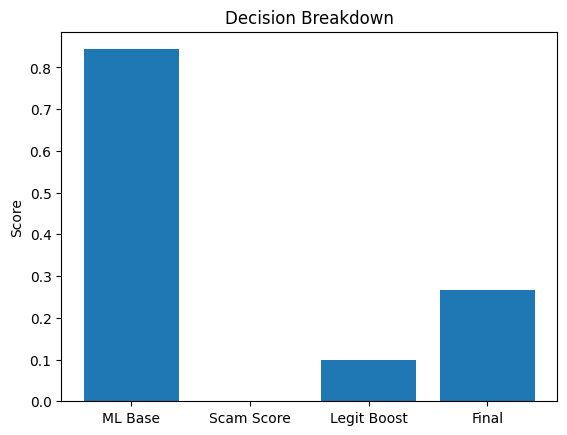

('✅ LEGIT', np.float64(0.26683333333333337))

In [104]:
predict('https://www.harvard.edu')



[INFO] Processing URL: https://www.microsoft.com
[DEBUG] Expanded URL: https://www.microsoft.com

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.4505
Base ML Probability  : 0.5300

===== ANALYSIS =====
Domain            : www.microsoft.com
HTTPS             : 1
Domain Age        : 12757
URL Length        : 26
Subdomains        : 1

[Reasons]
- Form present


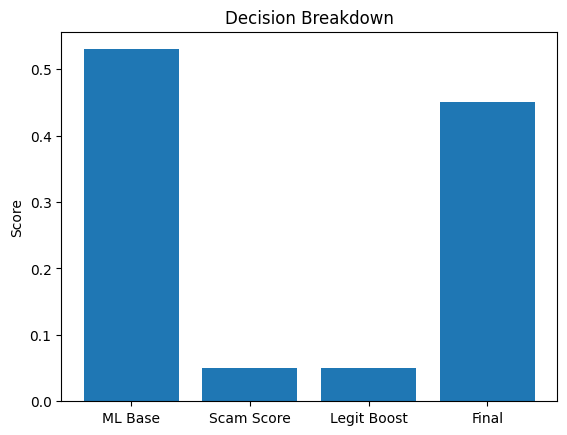

('✅ LEGIT', np.float64(0.45050000000000007))

In [105]:
predict('https://www.microsoft.com')



[INFO] Processing URL: https://www.tcs.com
[DEBUG] Expanded URL: https://www.tcs.com

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.4883
Base ML Probability  : 0.6333

===== ANALYSIS =====
Domain            : www.tcs.com
HTTPS             : 1
Domain Age        : 10358
URL Length        : 19
Subdomains        : 1

[Reasons]


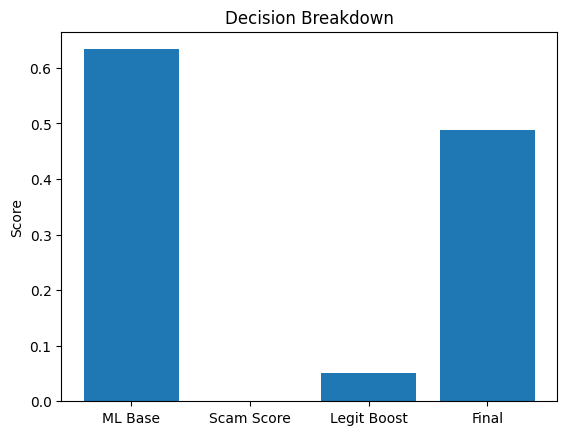

('✅ LEGIT', np.float64(0.48833333333333334))

In [106]:
predict('https://www.tcs.com')



[INFO] Processing URL: https://t.co/example
[DEBUG] Expanded URL: https://t.co/example

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS (Shortened URL)
Final Probability    : 1.0000
Base ML Probability  : 0.8533

===== ANALYSIS =====
Domain            : t.co
HTTPS             : 1
Domain Age        : None
URL Length        : 20
Subdomains        : 0

[Reasons]
- Unknown domain age
- Shortened URL


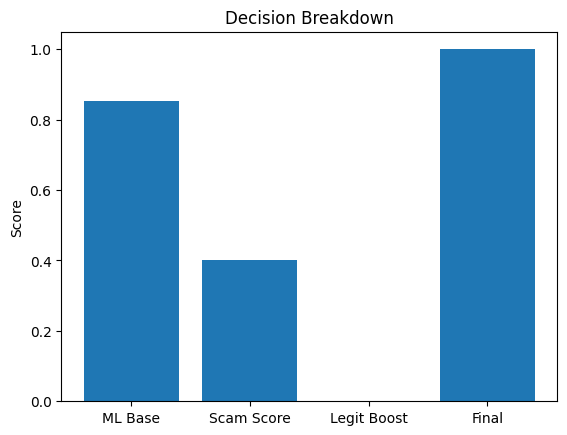

('⚠️ SUSPICIOUS (Shortened URL)', 1.0)

In [107]:
predict('https://t.co/example')



[INFO] Processing URL: https://paypal-login-help.com
[DEBUG] Expanded URL: https://paypal-login-help.com

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9133

===== ANALYSIS =====
Domain            : paypal-login-help.com
HTTPS             : 1
Domain Age        : None
URL Length        : 29
Subdomains        : 0

[Reasons]
- Unknown domain age
- Suspicious path keywords


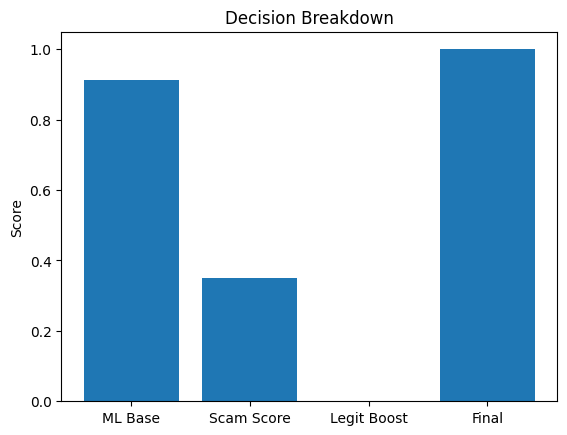

('🚨 SCAM (HIGH RISK)', 1.0)

In [108]:
predict('https://paypal-login-help.com')



[INFO] Processing URL: http://account-check.ga
[DEBUG] Expanded URL: http://account-check.ga

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9700

===== ANALYSIS =====
Domain            : account-check.ga
HTTPS             : 0
Domain Age        : None
URL Length        : 23
Subdomains        : 0

[Reasons]
- Unknown domain age
- Suspicious TLD
- Suspicious path keywords


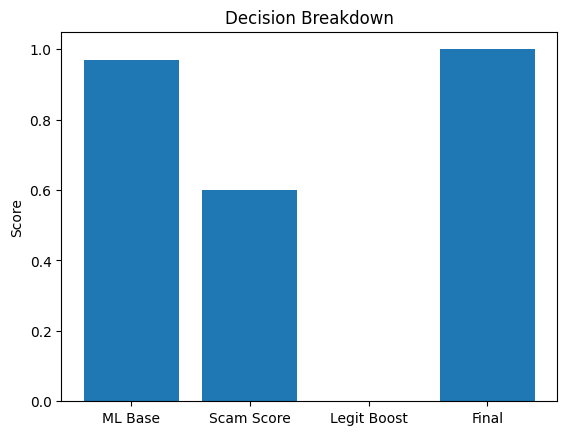

('🚨 SCAM (HIGH RISK)', 1.0)

In [109]:
predict('http://account-check.ga')



[INFO] Processing URL: https://docs.python.org
[DEBUG] Expanded URL: https://docs.python.org/3/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3230
Base ML Probability  : 0.3800

===== ANALYSIS =====
Domain            : docs.python.org
HTTPS             : 1
Domain Age        : 11332
URL Length        : 26
Subdomains        : 1

[Reasons]
- Form present


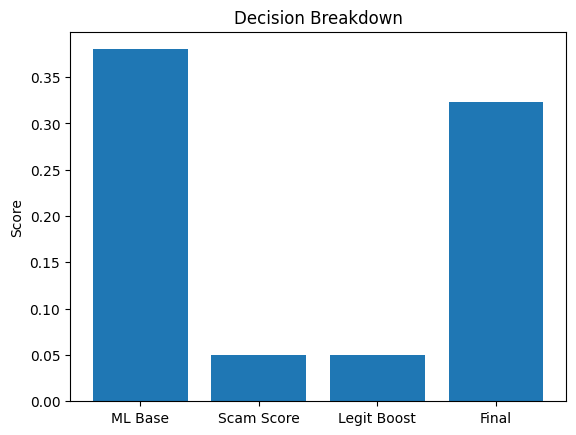

('✅ LEGIT', np.float64(0.323))

In [110]:
predict('https://docs.python.org')



[INFO] Processing URL: https://google-account-verification-alert.net
[DEBUG] Expanded URL: https://google-account-verification-alert.net

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9100

===== ANALYSIS =====
Domain            : google-account-verification-alert.net
HTTPS             : 1
Domain Age        : None
URL Length        : 45
Subdomains        : 0

[Reasons]
- Unknown domain age
- Suspicious path keywords


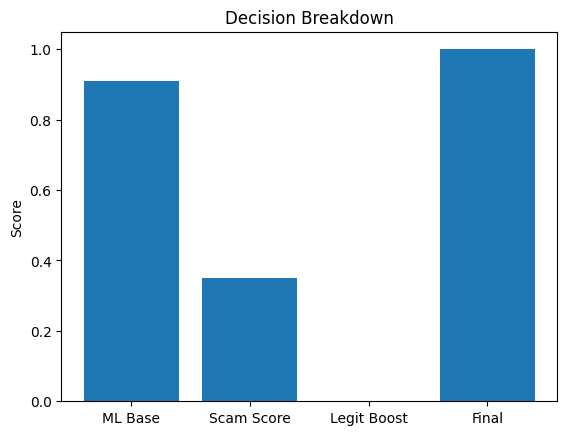

('🚨 SCAM (HIGH RISK)', 1.0)

In [111]:
predict('https://google-account-verification-alert.net')



[INFO] Processing URL: https://att-102546.weeblysite.com/
[DEBUG] Expanded URL: https://att-102546.weeblysite.com/

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.8148
Base ML Probability  : 0.7233

===== ANALYSIS =====
Domain            : att-102546.weeblysite.com
HTTPS             : 1
Domain Age        : 4855
URL Length        : 34
Subdomains        : 1

[Reasons]
- Free hosting domain


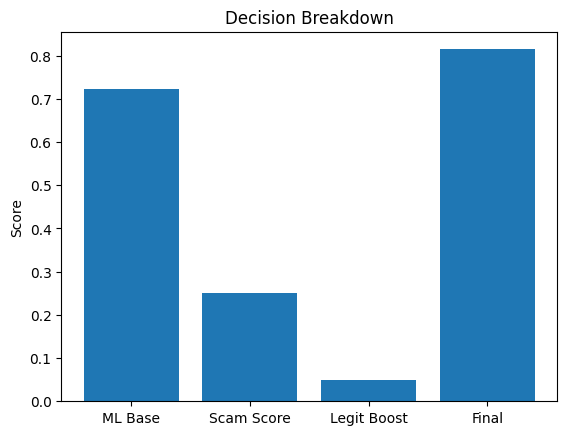

('🚨 SCAM (HIGH RISK)', np.float64(0.8148333333333333))

In [112]:
predict('https://att-102546.weeblysite.com/')


[INFO] Processing URL: https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php
[DEBUG] Expanded URL: https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.8600

===== ANALYSIS =====
Domain            : m1csspartnero.wpenginepowered.com
HTTPS             : 1
Domain Age        : 2143
URL Length        : 72
Subdomains        : 1

[Reasons]
- Suspicious hosting domain
- Suspicious path keywords


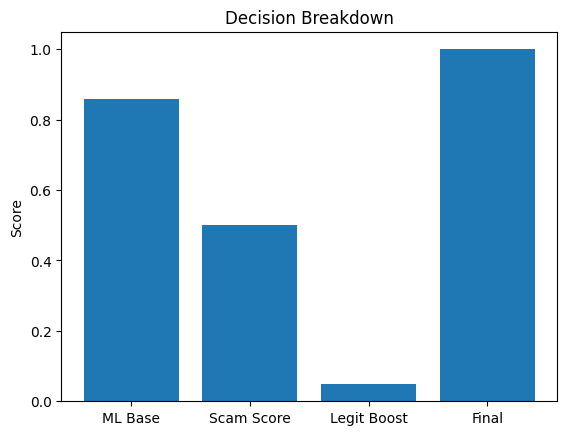

('🚨 SCAM (HIGH RISK)', 1.0)

In [113]:
predict('https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php')



[INFO] Processing URL: https://urlz.fr/uMHD
[DEBUG] Expanded URL: https://urlz.fr/uMHD

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.8555
Base ML Probability  : 0.8300

===== ANALYSIS =====
Domain            : urlz.fr
HTTPS             : 1
Domain Age        : None
URL Length        : 20
Subdomains        : 0

[Reasons]
- Unknown domain age


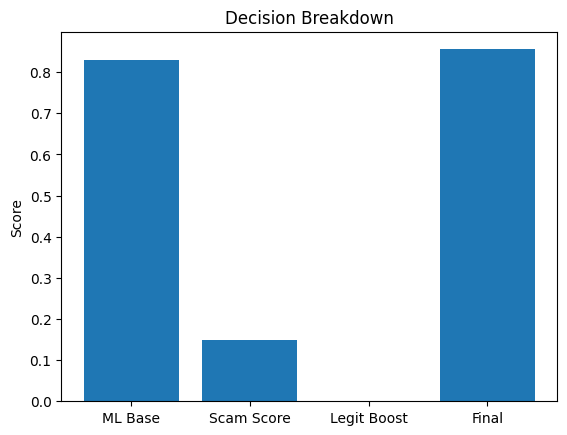

('🚨 SCAM (HIGH RISK)', np.float64(0.8554999999999999))

In [114]:
predict('https://urlz.fr/uMHD')



[INFO] Processing URL: https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f
[DEBUG] Expanded URL: https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9158
Base ML Probability  : 0.7833

===== ANALYSIS =====
Domain            : vh454.timeweb.ru
HTTPS             : 1
Domain Age        : None
URL Length        : 90
Subdomains        : 1

[Reasons]
- Unknown domain age
- Very long URL
- Form present


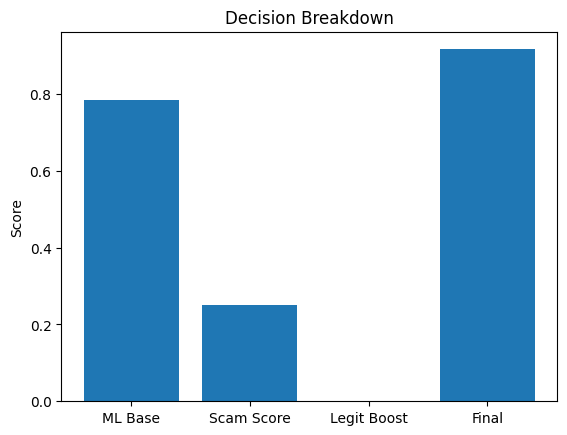

('🚨 SCAM (HIGH RISK)', np.float64(0.9158333333333333))

In [115]:
predict('https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f')



[INFO] Processing URL: https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g
[DEBUG] Expanded URL: https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9167

===== ANALYSIS =====
Domain            : update-limited-offer.tk
HTTPS             : 1
Domain Age        : None
URL Length        : 64
Subdomains        : 0

[Reasons]
- Unknown domain age
- Suspicious TLD
- Suspicious path keywords


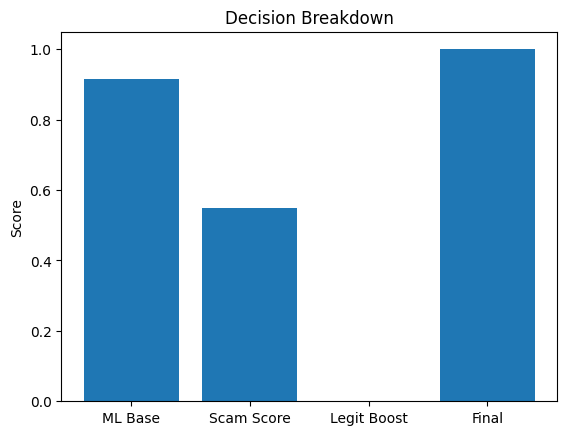

('🚨 SCAM (HIGH RISK)', 1.0)

In [116]:
predict('https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g')



[INFO] Processing URL: http://www.ippt.pan.pl/en/
[DEBUG] Expanded URL: http://www.ippt.pan.pl/en/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3065
Base ML Probability  : 0.8900

===== ANALYSIS =====
Domain            : www.ippt.pan.pl
HTTPS             : 0
Domain Age        : None
URL Length        : 26
Subdomains        : 2

[Reasons]
- High-trust domain (gov/edu)
- No HTTPS (trusted legacy site)
- Adjusted for trusted academic/gov domain


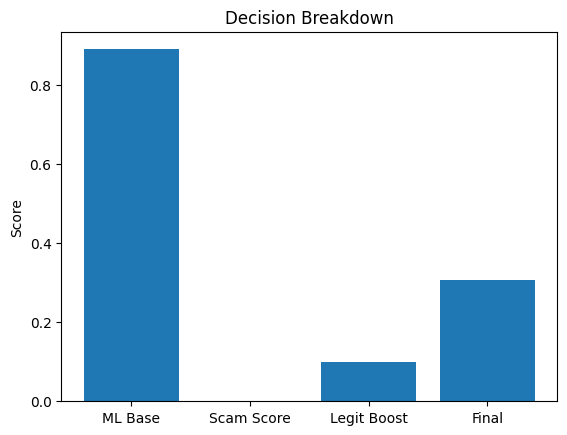

('✅ LEGIT', np.float64(0.3065))

In [117]:
predict('http://www.ippt.pan.pl/en/')



[INFO] Processing URL: http://www.uam.mx/
[DEBUG] Expanded URL: https://www.uam.mx/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3093
Base ML Probability  : 0.8933

===== ANALYSIS =====
Domain            : www.uam.mx
HTTPS             : 1
Domain Age        : None
URL Length        : 19
Subdomains        : 1

[Reasons]
- High-trust domain (gov/edu)
- Adjusted for trusted academic/gov domain


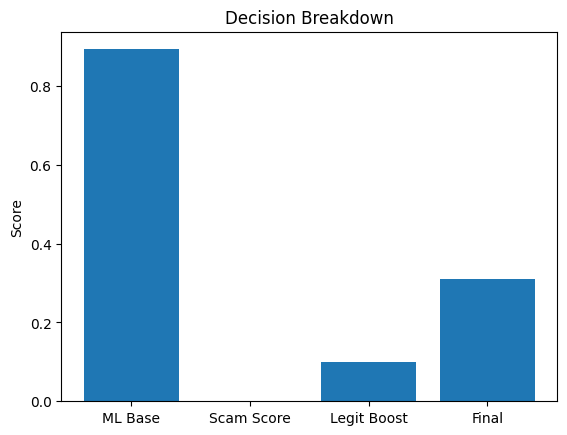

('✅ LEGIT', np.float64(0.30933333333333335))

In [118]:
predict('http://www.uam.mx/')



[INFO] Processing URL: http://www.westminster.ac.uk/
[DEBUG] Expanded URL: https://www.westminster.ac.uk/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.2867
Base ML Probability  : 0.8667

===== ANALYSIS =====
Domain            : www.westminster.ac.uk
HTTPS             : 1
Domain Age        : None
URL Length        : 30
Subdomains        : 2

[Reasons]
- High-trust domain (gov/edu)
- Adjusted for trusted academic/gov domain


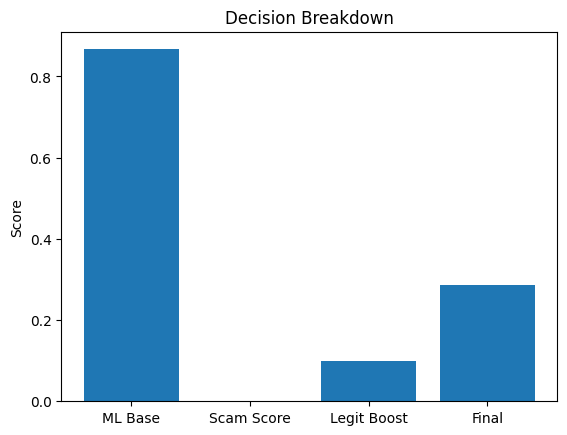

('✅ LEGIT', np.float64(0.28666666666666674))

In [119]:
predict('http://www.westminster.ac.uk/')



[INFO] Processing URL: https://167.99.167.250:19653/redeem-gift
[DEBUG] Expanded URL: https://167.99.167.250:19653/redeem-gift

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9235
Base ML Probability  : 0.9100

===== ANALYSIS =====
Domain            : 167.99.167.250:19653
HTTPS             : 1
Domain Age        : None
URL Length        : 40
Subdomains        : 2

[Reasons]
- Unknown domain age


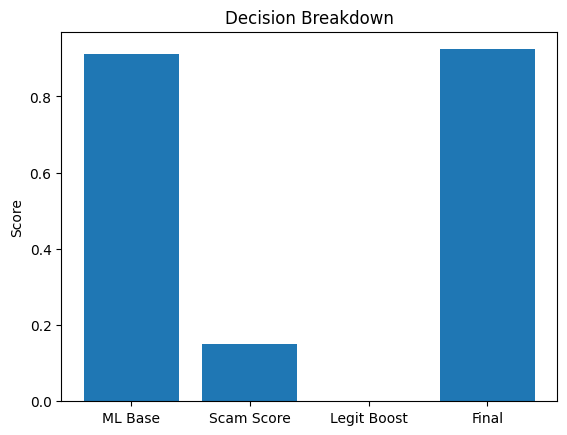

('🚨 SCAM (HIGH RISK)', np.float64(0.9235))

In [120]:
predict('https://167.99.167.250:19653/redeem-gift')



[INFO] Processing URL: http://bit.ly/5kWEh3S
[DEBUG] Expanded URL: http://bit.ly/5kWEh3S

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS (Shortened URL)
Final Probability    : 0.7912
Base ML Probability  : 0.6367

===== ANALYSIS =====
Domain            : bit.ly
HTTPS             : 0
Domain Age        : 6531
URL Length        : 21
Subdomains        : 0

[Reasons]
- Shortened URL


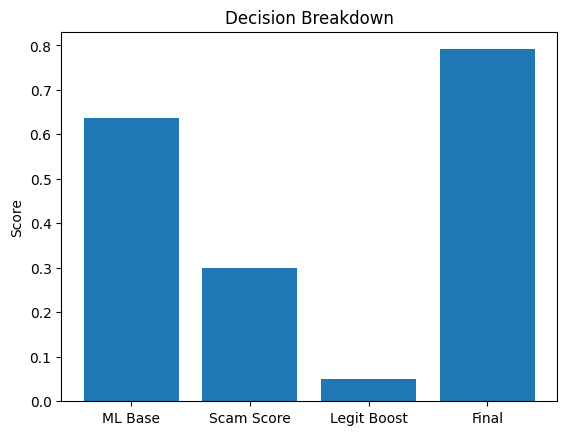

('⚠️ SUSPICIOUS (Shortened URL)', np.float64(0.7911666666666666))

In [121]:
predict('http://bit.ly/5kWEh3S')



[INFO] Processing URL: http://www.steel-sci.org
[DEBUG] Expanded URL: http://steel-sci.com

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.4052
Base ML Probability  : 0.4767

===== ANALYSIS =====
Domain            : steel-sci.com
HTTPS             : 1
Domain Age        : 11123
URL Length        : 22
Subdomains        : 0

[Reasons]
- Form present


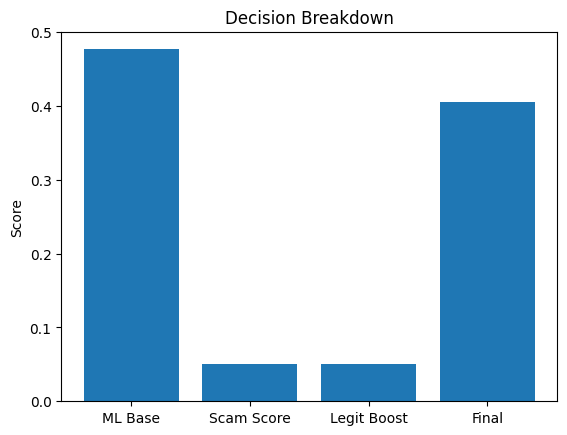

('✅ LEGIT', np.float64(0.4051666666666667))

In [122]:
predict('http://www.steel-sci.org')



[INFO] Processing URL: https://www.siemens.com/global/en/home.html
[DEBUG] Expanded URL: https://www.siemens.com/en-us/

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS
Final Probability    : 0.7110
Base ML Probability  : 0.6600

===== ANALYSIS =====
Domain            : www.siemens.com
HTTPS             : 1
Domain Age        : None
URL Length        : 30
Subdomains        : 1

[Reasons]
- Unknown domain age


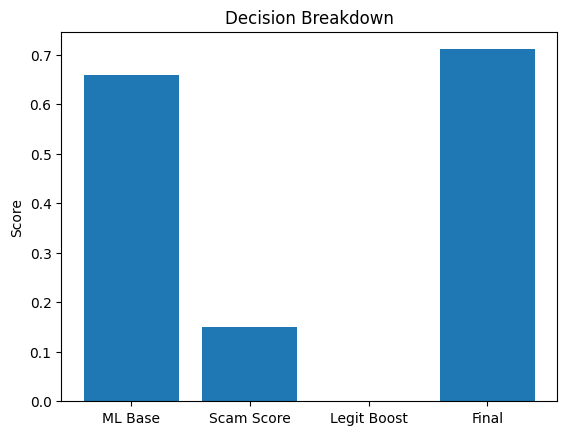

('⚠️ SUSPICIOUS', np.float64(0.7110000000000001))

In [123]:
predict('https://www.siemens.com/global/en/home.html')



[INFO] Processing URL: https://moon092.gaegs.com
[DEBUG] Expanded URL: https://moon092.gaegs.com

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.8967
Base ML Probability  : 0.8967

===== ANALYSIS =====
Domain            : moon092.gaegs.com
HTTPS             : 1
Domain Age        : 2057
URL Length        : 26
Subdomains        : 1

[Reasons]


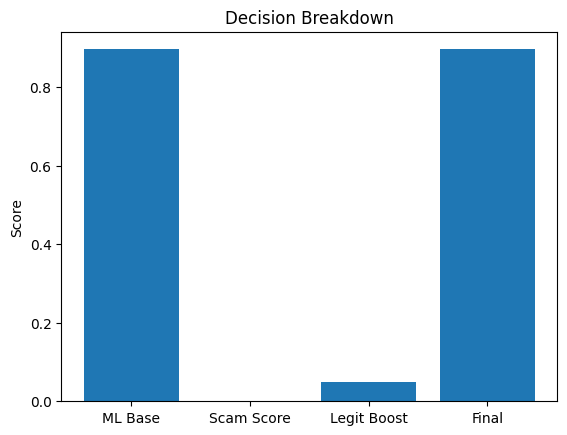

('🚨 SCAM (HIGH RISK)', np.float64(0.8966666666666666))

In [124]:
predict('https://moon092.gaegs.com')



[INFO] Processing URL: https://icici-alert-login.org
[DEBUG] Expanded URL: https://icici-alert-login.org

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9133

===== ANALYSIS =====
Domain            : icici-alert-login.org
HTTPS             : 1
Domain Age        : None
URL Length        : 29
Subdomains        : 0

[Reasons]
- Brand spoofing detected
- Unknown domain age
- Suspicious path keywords


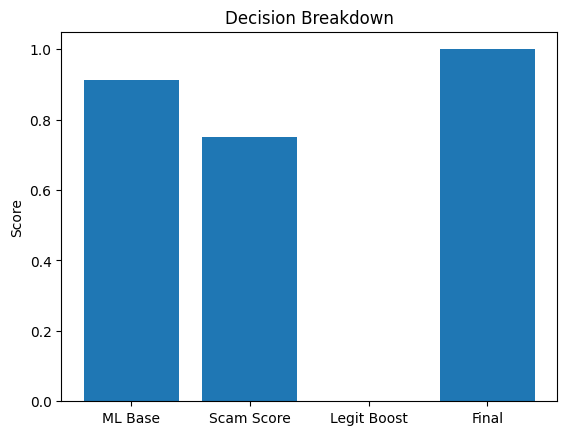

('🚨 SCAM (HIGH RISK)', 1.0)

In [125]:
predict('icici-alert-login.org')


In [126]:
# predict('')


In [127]:
# predict('')
